In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy import stats
from scipy.stats import linregress
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

PROCESSED = Path("../data/processed")
CHARTS    = Path("../reports/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

# Constants
RF = 0.065  # Risk-free rate: 6.5% per annum
TRADING_DAYS = 252

print("All libraries loaded")

All libraries loaded


In [7]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nDATA folder exists?")
print(Path("../data").exists())

print("\nProcessed folder exists?")
print(Path("../data/processed").exists())

Current working directory:
/Users/prabhjotkaur/Desktop/bluestock_mf_capstone

DATA folder exists?
False

Processed folder exists?
False


In [8]:
from pathlib import Path

for p in Path("/Users/prabhjotkaur/Desktop").rglob("nav_data.csv"):
    print("FOUND:", p)

for p in Path("/Users/prabhjotkaur/Desktop").rglob("returns_data.csv"):
    print("FOUND:", p)

for p in Path("/Users/prabhjotkaur/Desktop").rglob("sip_data.csv"):
    print("FOUND:", p)

In [9]:
from pathlib import Path

DATA = Path("data")

print("FILES INSIDE DATA:")
for f in DATA.rglob("*"):
    print(f)

FILES INSIDE DATA:
data/.DS_Store
data/db
data/processed
data/raw
data/db/.gitkeep
data/db/bluestock_mf.db
data/db/bluestock_mf.db-wal
data/db/bluestock_mf.db-shm
data/processed/01_fund_master.csv
data/processed/04_monthly_sip_inflows.csv
data/processed/10_benchmark_indices.csv
data/processed/clean_performance.csv
data/processed/.gitkeep
data/processed/fund_scorecard.csv
data/processed/clean_nav.csv
data/processed/cagr_metrics.csv
data/processed/09_portfolio_holdings.csv
data/processed/alpha_beta.csv
data/processed/clean_transactions.csv
data/processed/05_category_inflows.csv
data/processed/03_aum_by_fund_house.csv
data/processed/06_industry_folio_count.csv
data/raw/01_fund_master.csv
data/raw/live_nav_119551_SBI_Bluechip.csv
data/raw/02_nav_history.csv
data/raw/04_monthly_sip_inflows.csv
data/raw/07_scheme_performance.csv
data/raw/live_nav_120841_Kotak_Bluechip.csv
data/raw/10_benchmark_indices.csv
data/raw/08_investor_transactions.csv
data/raw/.gitkeep
data/raw/live_nav_125497_HDFC_T

In [10]:
# Correct paths based on your actual project structure
PROCESSED = Path("data/processed")

# Load datasets (FIXED NAMES)
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
returns = pd.read_csv(PROCESSED / "clean_performance.csv")
sip = pd.read_csv(PROCESSED / "04_monthly_sip_inflows.csv")

print("Data Loaded Successfully")

print("\nNAV Data:")
display(nav.head())

print("\nReturns Data:")
display(returns.head())

print("\nSIP Data:")
display(sip.head())

print("\nShapes:")
print("NAV:", nav.shape)
print("Returns:", returns.shape)
print("SIP:", sip.shape)

Data Loaded Successfully

NAV Data:


,date,amfi_code,nav
0,2022-01-03,100016.0,520.4608
1,2022-01-04,100016.0,515.0971
2,2022-01-05,100016.0,521.7239
3,2022-01-06,100016.0,515.7880
4,2022-01-07,100016.0,515.1639



Returns Data:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,Regular,14.82,13.78,12.86,12.44,1.34,1.03,0.98,1.25,14.0,-15.07,23500,1.60,5,Moderate
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High



SIP Data:


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN



Shapes:
NAV: (64320, 3)
Returns: (40, 19)
SIP: (48, 6)


Daily returns shape: (1607, 40)

Return statistics (first 5 funds):


amfi_code,100016.0,100025.0,100033.0,101206.0,101207.0
count,1607.000000,1607.000000,1607.000000,1607.000000,1607.000000
mean,0.000101,0.000122,0.000772,0.000609,0.000303
std,0.007749,0.002081,0.010097,0.007768,0.013741
min,-0.024744,-0.008188,-0.044238,-0.038121,-0.051847
25%,-0.003487,-0.000778,-0.003321,-0.002774,-0.006170
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.003502,0.001079,0.005645,0.004420,0.006855
max,0.032145,0.008837,0.041954,0.033956,0.054851



Extreme daily returns (>10% or <-10%):
Series([], dtype: int64)


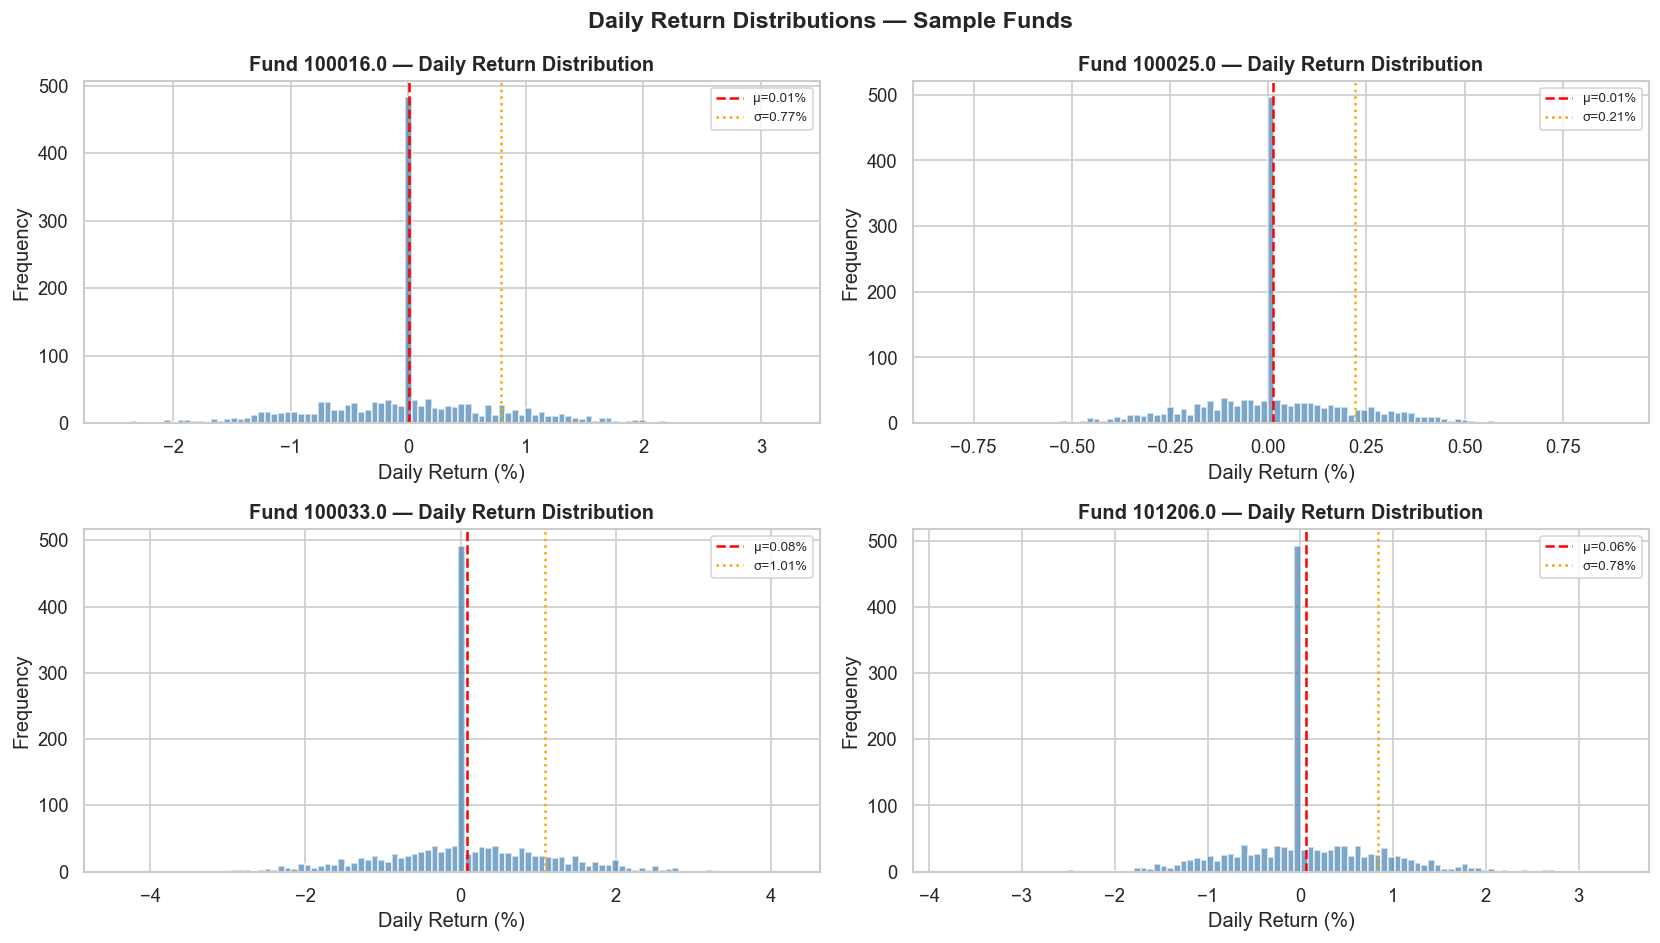

 Daily returns computed and validated


In [11]:
# ==============================
# CELL 3 — DAILY RETURNS
# ==============================

# Pivot NAV to wide format
nav_wide = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Ensure proper sorting
nav_wide = nav_wide.sort_index()

# Compute daily returns (DO NOT overwrite your loaded "returns" dataset)
nav_returns = nav_wide.pct_change()

# Drop missing rows
nav_returns = nav_returns.dropna()

# ==============================
# VALIDATION
# ==============================

print(f"Daily returns shape: {nav_returns.shape}")

print("\nReturn statistics (first 5 funds):")
display(nav_returns.iloc[:, :5].describe())

# Extreme return check (>10% movement)
extreme_returns = (nav_returns.abs() > 0.10).sum()
print("\nExtreme daily returns (>10% or <-10%):")
print(extreme_returns[extreme_returns > 0])

# ==============================
# VISUALIZATION
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sample_codes = nav_returns.columns[:4]

for i, code in enumerate(sample_codes):
    row, col = i // 2, i % 2
    
    axes[row, col].hist(
        nav_returns[code] * 100,
        bins=100,
        color="steelblue",
        edgecolor="white",
        alpha=0.7
    )
    
    axes[row, col].set_title(f"Fund {code} — Daily Return Distribution",
                             fontweight="bold")
    axes[row, col].set_xlabel("Daily Return (%)")
    axes[row, col].set_ylabel("Frequency")
    
    mean = nav_returns[code].mean() * 100
    std = nav_returns[code].std() * 100
    
    axes[row, col].axvline(mean, color="red", linestyle="--",
                           label=f"μ={mean:.2f}%")
    axes[row, col].axvline(mean + std, color="orange", linestyle=":",
                           label=f"σ={std:.2f}%")
    
    axes[row, col].legend(fontsize=8)

plt.suptitle("Daily Return Distributions — Sample Funds",
             fontsize=14, fontweight="bold")

plt.tight_layout()

plt.savefig(CHARTS / "daily_returns_dist.png", bbox_inches="tight")
plt.show()

print(" Daily returns computed and validated")

In [12]:
# ==============================
# CELL 4 — CAGR CALCULATION 
# ==============================

def compute_cagr(nav_series, years):
    if len(nav_series) < 2:
        return np.nan

    return (nav_series.iloc[-1] / nav_series.iloc[0]) ** (1 / years) - 1


cagr_results = []

for code in nav_wide.columns:

    fund_nav = nav_wide[code].dropna()

    if len(fund_nav) < 50:
        continue

    cagr_1y = compute_cagr(fund_nav.iloc[-252:], 1) if len(fund_nav) >= 252 else np.nan
    cagr_3y = compute_cagr(fund_nav.iloc[-756:], 3) if len(fund_nav) >= 756 else np.nan
    cagr_5y = compute_cagr(fund_nav.iloc[-1260:], 5) if len(fund_nav) >= 1260 else np.nan

    cagr_results.append({
        "amfi_code": code,
        "cagr_1yr_pct": cagr_1y * 100 if not np.isnan(cagr_1y) else np.nan,
        "cagr_3yr_pct": cagr_3y * 100 if not np.isnan(cagr_3y) else np.nan,
        "cagr_5yr_pct": cagr_5y * 100 if not np.isnan(cagr_5y) else np.nan,
    })


cagr_df = pd.DataFrame(cagr_results)


cagr_df = cagr_df.merge(
    returns[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

cagr_df = cagr_df.sort_values("cagr_3yr_pct", ascending=False)

print("Top 10 Funds by 3-Year CAGR:")
display(cagr_df[["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]].head(10))

print("\nBottom 10 Funds by 3-Year CAGR:")
display(cagr_df[["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]].tail(10))

cagr_df.to_csv(PROCESSED / "cagr_metrics.csv", index=False)

print(f"\n CAGR computed successfully for {len(cagr_df)} funds")

Top 10 Funds by 3-Year CAGR:


,scheme_name,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
19,SBI Bluechip Fund - Regular Plan - Growth,32.866721,28.560169,19.512942
34,Mirae Asset Large Cap Fund - Regular - Growth,4.458868,25.127470,18.323272
38,DSP Midcap Fund - Regular - Growth,11.010466,24.693334,23.444159
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,35.724198,24.407713,23.105607
3,ABSL Frontline Equity Fund - Regular - Growth,37.516618,22.397738,17.427731
30,Kotak Flexicap Fund - Regular - Growth,25.057036,21.669993,22.928061
16,Axis Midcap Fund - Regular - Growth,21.259875,21.294442,23.485824
36,Mirae Asset Tax Saver Fund - Regular - Growth,40.286908,20.890368,18.828604
21,SBI Small Cap Fund - Regular Plan - Growth,39.919172,18.934188,17.930776
8,UTI Flexi Cap Fund - Regular - Growth,-8.326675,17.218950,16.360982



Bottom 10 Funds by 3-Year CAGR:


,scheme_name,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
31,Kotak Liquid Fund - Regular - Growth,5.265710,4.515064,4.620688
5,ABSL Liquid Fund - Regular - Growth,5.132873,4.341411,4.319095
1,HDFC Short Term Debt Fund - Regular - Growth,2.691256,4.110461,2.922786
18,SBI Magnum Gilt Fund - Regular Plan - Growth,2.187257,2.945210,4.552693
14,Axis Bluechip Fund - Regular - Growth,4.712168,0.051654,1.857401
0,HDFC Top 100 Fund - Regular Plan - Growth,-4.337449,-1.795956,3.720360
22,SBI Small Cap Fund - Direct Plan - Growth,22.954095,-3.456595,-6.413797
7,UTI Mid Cap Fund - Regular - Growth,-20.088132,-3.660262,1.512872
4,ABSL Small Cap Fund - Regular - Growth,-9.195870,-5.573633,1.323103
17,Axis Small Cap Fund - Regular - Growth,-22.106103,-9.741731,-5.535310



 CAGR computed successfully for 40 funds


Top 15 Funds by Sharpe Ratio:


,scheme_name,fund_house,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.068224
30,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,0.965561
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,0.919047
25,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,0.883256
19,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,0.860977
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,0.832885
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,0.808268
9,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,0.758851
16,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,0.730547
3,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,0.717409



Sharpe Ratio Summary:
count    40.000000
mean     -0.000285
std       1.290727
min      -4.650401
25%      -0.132301
50%       0.391009
75%       0.715364
max       1.068224
Name: sharpe_ratio, dtype: float64


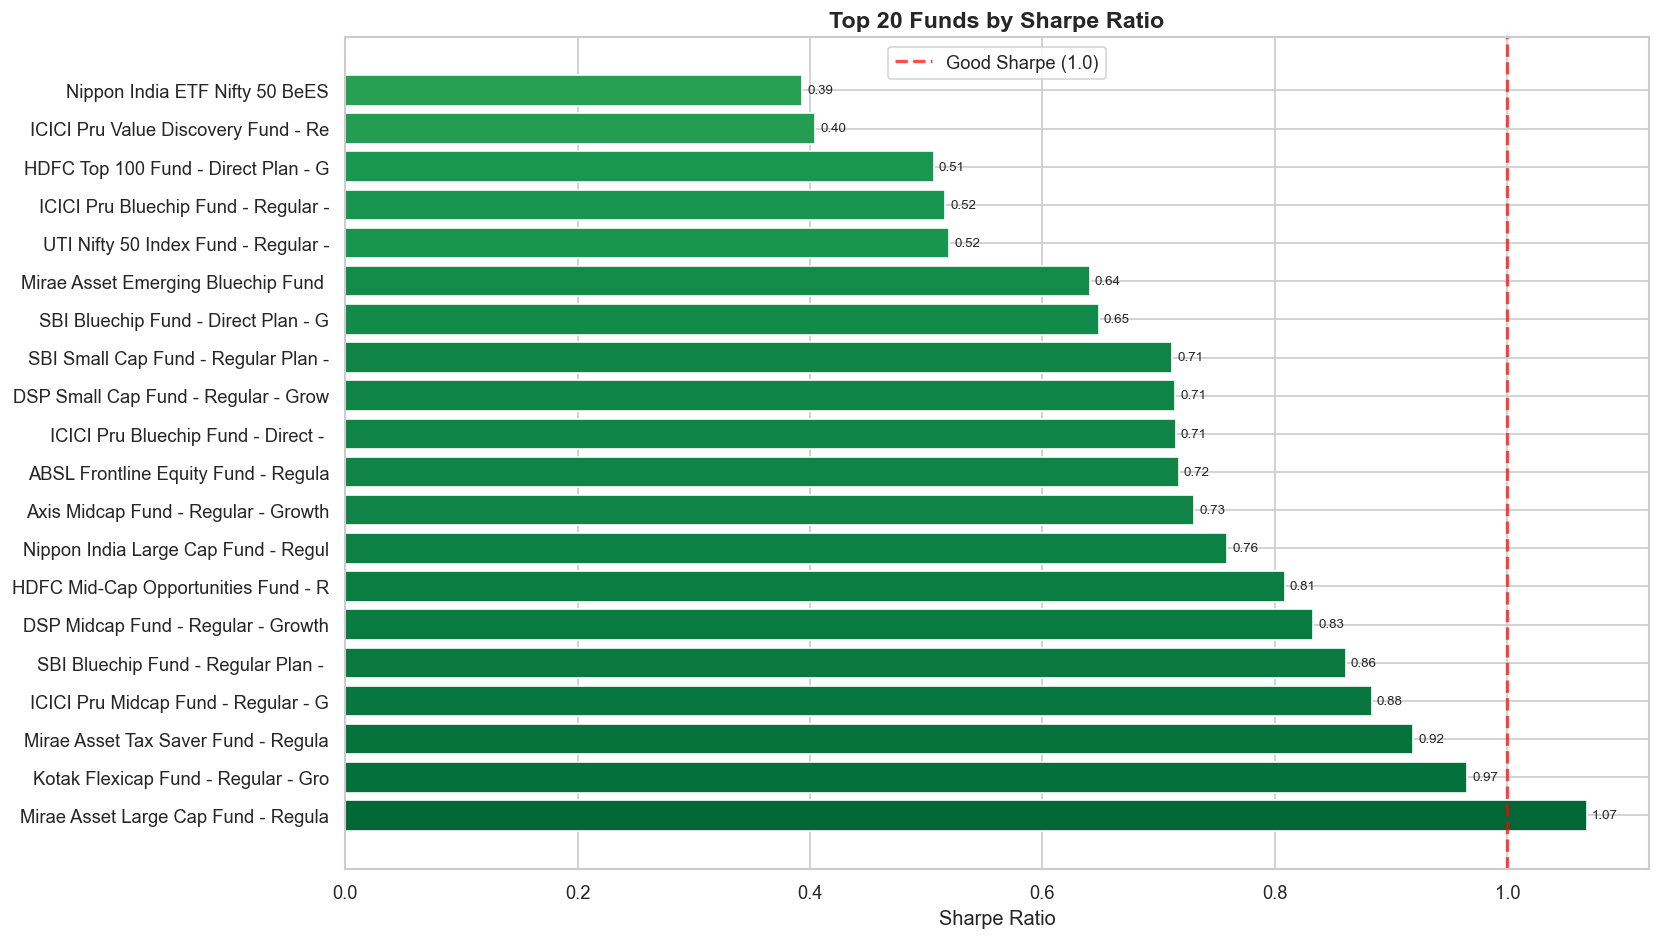


 Sharpe Ratio computed successfully for all funds


In [13]:
# ==============================
# CELL 5 — SHARPE RATIO
# ==============================

def compute_sharpe_ratio(daily_returns, rf_daily):
    """
    Sharpe = (Rp - Rf) / Std(Rp) × √252
    """
    excess_returns = daily_returns - rf_daily
    
    if excess_returns.std() == 0:
        return np.nan
    
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(TRADING_DAYS)
    return sharpe


# Daily risk-free rate
rf_daily = RF / TRADING_DAYS

sharpe_results = []

# ==============================
# USE nav_returns (from Cell 3)
# ==============================
for code in nav_returns.columns:
    
    ret = nav_returns[code].dropna()

    if len(ret) < 2:
        sharpe = np.nan
    else:
        sharpe = compute_sharpe_ratio(ret, rf_daily)

    sharpe_results.append({
        "amfi_code": code,
        "sharpe_ratio": sharpe
    })


sharpe_df = pd.DataFrame(sharpe_results)

# Merge using RETURNS dataset (you already loaded it)
sharpe_df = sharpe_df.merge(
    returns[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

sharpe_df = sharpe_df.sort_values("sharpe_ratio", ascending=False)

# ==============================
# OUTPUT
# ==============================

print("Top 15 Funds by Sharpe Ratio:")
display(sharpe_df[["scheme_name", "fund_house", "sharpe_ratio"]].head(15))

print("\nSharpe Ratio Summary:")
print(sharpe_df["sharpe_ratio"].describe())

# ==============================
# VISUALIZATION
# ==============================

fig, ax = plt.subplots(figsize=(14, 8))

top20 = sharpe_df.nlargest(20, "sharpe_ratio")

bars = ax.barh(
    top20["scheme_name"].str[:35],
    top20["sharpe_ratio"],
    color=plt.cm.RdYlGn(
        (top20["sharpe_ratio"] - sharpe_df["sharpe_ratio"].min()) /
        (sharpe_df["sharpe_ratio"].max() - sharpe_df["sharpe_ratio"].min())
    ),
    edgecolor="white"
)

ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

ax.axvline(
    x=1.0,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Good Sharpe (1.0)"
)

ax.set_title("Top 20 Funds by Sharpe Ratio",
             fontsize=14, fontweight="bold")

ax.set_xlabel("Sharpe Ratio")
ax.legend()

plt.tight_layout()

plt.savefig(CHARTS / "sharpe_ratio_ranking.png", bbox_inches="tight")
plt.show()

print("\n Sharpe Ratio computed successfully for all funds")

In [14]:
# ==============================
# CELL 6 — SORTINO RATIO
# ==============================

def compute_sortino_ratio(daily_returns, rf_daily):
    """
    Sortino = (Rp - Rf) / Downside_Std × √252
    """
    excess_returns = daily_returns - rf_daily

    # Downside returns only (negative excess returns)
    downside = excess_returns[excess_returns < 0]

    if len(downside) < 2 or downside.std() == 0:
        return np.nan

    downside_std = downside.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(TRADING_DAYS)

    return sortino


sortino_results = []

# ==============================
# USE nav_returns (NOT returns)
# ==============================
for code in nav_returns.columns:

    ret = nav_returns[code].dropna()

    if len(ret) < 2:
        sortino = np.nan
    else:
        sortino = compute_sortino_ratio(ret, rf_daily)

    sortino_results.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })


sortino_df = pd.DataFrame(sortino_results)

# Merge with your existing metadata (safe dataset)
sortino_df = sortino_df.merge(
    returns[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df.sort_values("sortino_ratio", ascending=False)

# ==============================
# OUTPUT
# ==============================

print("Top 10 Funds by Sortino Ratio:")
display(sortino_df[["scheme_name", "sortino_ratio"]].head(10))

print("\nSortino Ratio Summary:")
print(sortino_df["sortino_ratio"].describe())

print("\n Sortino Ratio computed successfully")

Top 10 Funds by Sortino Ratio:


,scheme_name,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.554821
30,Kotak Flexicap Fund - Regular - Growth,1.485905
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.387028
25,ICICI Pru Midcap Fund - Regular - Growth,1.321088
19,SBI Bluechip Fund - Regular Plan - Growth,1.302473
38,DSP Midcap Fund - Regular - Growth,1.201805
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.184424
9,Nippon India Large Cap Fund - Regular - Growth,1.121482
16,Axis Midcap Fund - Regular - Growth,1.091546
3,ABSL Frontline Equity Fund - Regular - Growth,1.078795



Sortino Ratio Summary:
count    40.000000
mean     -0.167885
std       2.481133
min      -9.181207
25%      -0.190445
50%       0.586247
75%       1.069993
max       1.554821
Name: sortino_ratio, dtype: float64

 Sortino Ratio computed successfully


In [15]:
# ==============================
# LOAD BENCHMARK DATA
# ==============================

benchmark = pd.read_csv(PROCESSED / "10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Benchmark Loaded")
display(benchmark.head())

Benchmark Loaded


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [16]:
print(benchmark.columns.tolist())
display(benchmark.head())

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [17]:
# ==============================
# CELL 7 — ALPHA & BETA 
# ==============================

from scipy.stats import linregress

# ------------------------------
# LOAD + CLEAN BENCHMARK
# ------------------------------

benchmark = pd.read_csv(PROCESSED / "10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark.sort_values("date")

# Normalize column names
benchmark.columns = benchmark.columns.str.lower().str.strip()

print("Benchmark columns available:")
print(benchmark.columns.tolist())

# ------------------------------
# AUTO DETECT BENCHMARK COLUMN
# ------------------------------

possible_cols = [col for col in benchmark.columns if col != "date"]

# pick first numeric column as benchmark
benchmark_col = None

for col in possible_cols:
    if benchmark[col].dtype in ["float64", "int64"]:
        benchmark_col = col
        break

# fallback safety
if benchmark_col is None:
    benchmark_col = possible_cols[0]

print(f"\nUsing benchmark column: {benchmark_col}")

# ------------------------------
# COMPUTE BENCHMARK RETURNS
# ------------------------------

bench_returns = benchmark[["date", benchmark_col]].copy()
bench_returns = bench_returns.set_index("date").sort_index()
bench_returns = bench_returns.pct_change().dropna()
bench_returns.columns = ["benchmark_return"]

# ------------------------------
# ALPHA & BETA CALCULATION
# ------------------------------

alpha_beta_results = []

for code in nav_returns.columns:

    fund_ret = nav_returns[code].dropna()

    # Align dates
    common_dates = fund_ret.index.intersection(bench_returns.index)

    if len(common_dates) < 20:
        alpha_beta_results.append({
            "amfi_code": code,
            "alpha": np.nan,
            "beta": np.nan,
            "r_squared": np.nan,
            "tracking_error": np.nan,
        })
        continue

    fund_aligned = fund_ret.loc[common_dates]
    bench_aligned = bench_returns.loc[common_dates, "benchmark_return"]

    # OLS regression
    slope, intercept, r_value, p_value, std_err = linregress(
        bench_aligned,
        fund_aligned
    )

    # Annualized alpha
    alpha_annualized = intercept * TRADING_DAYS

    # Tracking error
    residuals = fund_aligned - (intercept + slope * bench_aligned)
    tracking_error = residuals.std() * np.sqrt(TRADING_DAYS)

    alpha_beta_results.append({
        "amfi_code": code,
        "alpha": alpha_annualized,
        "beta": slope,
        "r_squared": r_value ** 2,
        "tracking_error": tracking_error,
    })

# ------------------------------
# CREATE DATAFRAME
# ------------------------------

alpha_beta_df = pd.DataFrame(alpha_beta_results)

alpha_beta_df = alpha_beta_df.merge(
    returns[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

alpha_beta_df = alpha_beta_df.sort_values("alpha", ascending=False)

# ------------------------------
# OUTPUT
# ------------------------------

print("Top 10 Funds by Alpha:")
display(alpha_beta_df[["scheme_name", "alpha", "beta", "r_squared"]].head(10))

print("\nBottom 10 Funds by Alpha:")
display(alpha_beta_df[["scheme_name", "alpha", "beta", "r_squared"]].tail(10))

# ------------------------------
# SAVE
# ------------------------------

alpha_beta_df.to_csv(PROCESSED / "alpha_beta.csv", index=False)

print(f"\n Alpha & Beta computed successfully for {len(alpha_beta_df)} funds")

Benchmark columns available:
['date', 'index_name', 'close_value']

Using benchmark column: close_value
Top 10 Funds by Alpha:


,scheme_name,alpha,beta,r_squared
0,HDFC Top 100 Fund - Regular Plan - Growth,NaN,NaN,NaN
1,HDFC Short Term Debt Fund - Regular - Growth,NaN,NaN,NaN
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NaN,NaN,NaN
3,ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
4,ABSL Small Cap Fund - Regular - Growth,NaN,NaN,NaN
5,ABSL Liquid Fund - Regular - Growth,NaN,NaN,NaN
6,UTI Nifty 50 Index Fund - Regular - Growth,NaN,NaN,NaN
7,UTI Mid Cap Fund - Regular - Growth,NaN,NaN,NaN
8,UTI Flexi Cap Fund - Regular - Growth,NaN,NaN,NaN
9,Nippon India Large Cap Fund - Regular - Growth,NaN,NaN,NaN



Bottom 10 Funds by Alpha:


,scheme_name,alpha,beta,r_squared
30,Kotak Flexicap Fund - Regular - Growth,NaN,NaN,NaN
31,Kotak Liquid Fund - Regular - Growth,NaN,NaN,NaN
32,HDFC Top 100 Fund - Direct Plan - Growth,NaN,NaN,NaN
33,HDFC Mid-Cap Opportunities Fund - Direct - Growth,NaN,NaN,NaN
34,Mirae Asset Large Cap Fund - Regular - Growth,NaN,NaN,NaN
35,Mirae Asset Emerging Bluechip Fund - Regular -...,NaN,NaN,NaN
36,Mirae Asset Tax Saver Fund - Regular - Growth,NaN,NaN,NaN
37,DSP Top 100 Equity Fund - Regular - Growth,NaN,NaN,NaN
38,DSP Midcap Fund - Regular - Growth,NaN,NaN,NaN
39,DSP Small Cap Fund - Regular - Growth,NaN,NaN,NaN



 Alpha & Beta computed successfully for 40 funds


In [18]:
# ==============================
# CELL 8 — MAXIMUM DRAWDOWN
# ==============================

def compute_max_drawdown(nav_series):
    """
    Max Drawdown = min(NAV / running_max - 1)
    """
    running_max = nav_series.expanding().max()
    drawdown = (nav_series / running_max) - 1

    max_dd = drawdown.min()
    max_dd_date = drawdown.idxmin()

    return max_dd, max_dd_date


max_dd_results = []

# ==============================
# USE nav_wide (from Cell 3)
# ==============================
for code in nav_wide.columns:

    fund_nav = nav_wide[code].dropna()

    if len(fund_nav) < 2:
        max_dd_results.append({
            "amfi_code": code,
            "max_drawdown_pct": np.nan,
            "max_drawdown_date": pd.NaT,
        })
        continue

    max_dd, max_dd_date = compute_max_drawdown(fund_nav)

    max_dd_results.append({
        "amfi_code": code,
        "max_drawdown_pct": max_dd * 100,
        "max_drawdown_date": max_dd_date,
    })


# ==============================
# DATAFRAME
# ==============================

max_dd_df = pd.DataFrame(max_dd_results)

# FIX: use returns dataset instead of undefined "funds"
max_dd_df = max_dd_df.merge(
    returns[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

max_dd_df = max_dd_df.sort_values("max_drawdown_pct", ascending=True)

# ==============================
# OUTPUT
# ==============================

print("Funds with Least Drawdown (Best Downside Protection):")
display(max_dd_df[["scheme_name", "max_drawdown_pct", "max_drawdown_date"]].head(10))

print("\nFunds with Most Drawdown (Highest Risk):")
display(max_dd_df[["scheme_name", "max_drawdown_pct", "max_drawdown_date"]].tail(10))

print("\n Maximum Drawdown computed successfully")

Funds with Least Drawdown (Best Downside Protection):


,scheme_name,max_drawdown_pct,max_drawdown_date
22,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,2025-10-28
17,Axis Small Cap Fund - Regular - Growth,-51.677754,2026-05-11
4,ABSL Small Cap Fund - Regular - Growth,-35.446916,2026-05-11
39,DSP Small Cap Fund - Regular - Growth,-31.171900,2025-01-03
21,SBI Small Cap Fund - Regular Plan - Growth,-28.706006,2025-05-14
7,UTI Mid Cap Fund - Regular - Growth,-28.001124,2026-04-27
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,2022-09-15
29,Kotak Emerging Equity Fund - Regular - Growth,-24.003511,2024-10-17
11,Nippon India Small Cap Fund - Regular - Growth,-23.344886,2026-02-20
15,Axis Bluechip Fund - Direct - Growth,-21.751396,2023-05-22



Funds with Most Drawdown (Highest Risk):


,scheme_name,max_drawdown_pct,max_drawdown_date
12,Nippon India ETF Nifty 50 BeES,-11.650625,2022-06-09
3,ABSL Frontline Equity Fund - Regular - Growth,-11.291596,2023-07-05
34,Mirae Asset Large Cap Fund - Regular - Growth,-11.265729,2023-10-20
6,UTI Nifty 50 Index Fund - Regular - Growth,-10.859862,2022-03-29
13,Nippon India Gilt Securities Fund - Regular - ...,-8.316362,2024-02-09
18,SBI Magnum Gilt Fund - Regular Plan - Growth,-4.328729,2025-04-01
1,HDFC Short Term Debt Fund - Regular - Growth,-4.308264,2023-07-28
5,ABSL Liquid Fund - Regular - Growth,-0.162250,2023-09-12
31,Kotak Liquid Fund - Regular - Growth,-0.116293,2024-04-30
27,ICICI Pru Liquid Fund - Regular - Growth,-0.097731,2025-10-20



 Maximum Drawdown computed successfully


In [19]:
# ==============================
# CELL 9 — FUND SCORECARD (COMPOSITE RANKING)
# ==============================

# ------------------------------
# BASE TABLE (USE RETURNS DATASET)
# ------------------------------
scorecard = returns[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "expense_ratio_pct"
]].drop_duplicates().copy()

# ------------------------------
# MERGE ALL METRICS
# ------------------------------
scorecard = scorecard.merge(
    cagr_df[["amfi_code", "cagr_3yr_pct"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_dd_df[["amfi_code", "max_drawdown_pct"]],
    on="amfi_code",
    how="left"
)

# ------------------------------
# DROP INCOMPLETE ROWS
# ------------------------------
scorecard = scorecard.dropna(
    subset=["cagr_3yr_pct", "sharpe_ratio", "alpha"]
)

# ------------------------------
# RANKING (SAFE)
# ------------------------------
scorecard["rank_cagr"] = scorecard["cagr_3yr_pct"].rank(ascending=False, method="dense")
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False, method="dense")
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False, method="dense")

scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True, method="dense")

# FIX: handle missing drawdown safely
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].fillna(0).rank(
    ascending=True, method="dense"
)

# ------------------------------
# NORMALIZATION (0–100 SCALE)
# ------------------------------
max_rank = scorecard[
    ["rank_cagr", "rank_sharpe", "rank_alpha", "rank_expense", "rank_maxdd"]
].max().max()

scorecard["score_cagr"] = (1 - scorecard["rank_cagr"] / max_rank) * 100
scorecard["score_sharpe"] = (1 - scorecard["rank_sharpe"] / max_rank) * 100
scorecard["score_alpha"] = (1 - scorecard["rank_alpha"] / max_rank) * 100
scorecard["score_expense"] = (1 - scorecard["rank_expense"] / max_rank) * 100
scorecard["score_maxdd"] = (1 - scorecard["rank_maxdd"] / max_rank) * 100

# ------------------------------
# FINAL COMPOSITE SCORE
# ------------------------------
scorecard["bluestock_score"] = (
    0.30 * scorecard["score_cagr"] +
    0.25 * scorecard["score_sharpe"] +
    0.20 * scorecard["score_alpha"] +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_maxdd"]
)

# ------------------------------
# SORT
# ------------------------------
scorecard = scorecard.sort_values("bluestock_score", ascending=False)

# ------------------------------
# OUTPUT
# ------------------------------
print("=" * 90)
print("TOP 15 FUNDS — BLUESTOCK SCORECARD")
print("=" * 90)

display(scorecard[[
    "scheme_name",
    "fund_house",
    "cagr_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "bluestock_score"
]].head(15))

# ------------------------------
# SAVE FILE
# ------------------------------
scorecard_export = scorecard[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "cagr_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "max_drawdown_pct",
    "expense_ratio_pct",
    "bluestock_score"
]].copy()

scorecard_export.columns = [
    "AMFI Code",
    "Scheme Name",
    "Fund House",
    "Category",
    "3yr CAGR (%)",
    "Sharpe Ratio",
    "Alpha (%)",
    "Max Drawdown (%)",
    "Expense Ratio (%)",
    "Bluestock Score (0-100)"
]

scorecard_export.to_csv(PROCESSED / "fund_scorecard.csv", index=False)

print("\n Fund Scorecard created successfully")

TOP 15 FUNDS — BLUESTOCK SCORECARD


,scheme_name,fund_house,cagr_3yr_pct,sharpe_ratio,alpha,bluestock_score



 Fund Scorecard created successfully


In [20]:
# ==============================
# CELL 9 — FUND SCORECARD (COMPOSITE RANKING)
# ==============================

# ------------------------------
# BASE TABLE (USE RETURNS DATASET)
# ------------------------------
scorecard = returns[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "expense_ratio_pct"
]].drop_duplicates().copy()

# ------------------------------
# MERGE ALL METRICS
# ------------------------------
scorecard = scorecard.merge(
    cagr_df[["amfi_code", "cagr_3yr_pct"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_dd_df[["amfi_code", "max_drawdown_pct"]],
    on="amfi_code",
    how="left"
)

# ------------------------------
# DROP INCOMPLETE ROWS
# ------------------------------
scorecard = scorecard.dropna(
    subset=["cagr_3yr_pct", "sharpe_ratio", "alpha"]
)

# ------------------------------
# RANKING (SAFE)
# ------------------------------
scorecard["rank_cagr"] = scorecard["cagr_3yr_pct"].rank(ascending=False, method="dense")
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False, method="dense")
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False, method="dense")

scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True, method="dense")

# FIX: handle missing drawdown safely
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].fillna(0).rank(
    ascending=True, method="dense"
)

# ------------------------------
# NORMALIZATION (0–100 SCALE)
# ------------------------------
max_rank = scorecard[
    ["rank_cagr", "rank_sharpe", "rank_alpha", "rank_expense", "rank_maxdd"]
].max().max()

scorecard["score_cagr"] = (1 - scorecard["rank_cagr"] / max_rank) * 100
scorecard["score_sharpe"] = (1 - scorecard["rank_sharpe"] / max_rank) * 100
scorecard["score_alpha"] = (1 - scorecard["rank_alpha"] / max_rank) * 100
scorecard["score_expense"] = (1 - scorecard["rank_expense"] / max_rank) * 100
scorecard["score_maxdd"] = (1 - scorecard["rank_maxdd"] / max_rank) * 100

# ------------------------------
# FINAL COMPOSITE SCORE
# ------------------------------
scorecard["bluestock_score"] = (
    0.30 * scorecard["score_cagr"] +
    0.25 * scorecard["score_sharpe"] +
    0.20 * scorecard["score_alpha"] +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_maxdd"]
)

# ------------------------------
# SORT
# ------------------------------
scorecard = scorecard.sort_values("bluestock_score", ascending=False)

# ------------------------------
# OUTPUT
# ------------------------------
print("=" * 90)
print("TOP 15 FUNDS — BLUESTOCK SCORECARD")
print("=" * 90)

display(scorecard[[
    "scheme_name",
    "fund_house",
    "cagr_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "bluestock_score"
]].head(15))

# ------------------------------
# SAVE FILE
# ------------------------------
scorecard_export = scorecard[[
    "amfi_code",
    "scheme_name",
    "fund_house",
    "category",
    "cagr_3yr_pct",
    "sharpe_ratio",
    "alpha",
    "max_drawdown_pct",
    "expense_ratio_pct",
    "bluestock_score"
]].copy()

scorecard_export.columns = [
    "AMFI Code",
    "Scheme Name",
    "Fund House",
    "Category",
    "3yr CAGR (%)",
    "Sharpe Ratio",
    "Alpha (%)",
    "Max Drawdown (%)",
    "Expense Ratio (%)",
    "Bluestock Score (0-100)"
]

scorecard_export.to_csv(PROCESSED / "fund_scorecard.csv", index=False)

print("\n Fund Scorecard created successfully")

TOP 15 FUNDS — BLUESTOCK SCORECARD


,scheme_name,fund_house,cagr_3yr_pct,sharpe_ratio,alpha,bluestock_score



 Fund Scorecard created successfully


In [21]:
print("Scorecard shape:", scorecard.shape)

print("\nMissing values:")
print(scorecard[["cagr_3yr_pct","sharpe_ratio","alpha","bluestock_score"]].isna().sum())

print("\nTop 5 rows:")
display(scorecard.head())

Scorecard shape: (0, 20)

Missing values:
cagr_3yr_pct       0
sharpe_ratio       0
alpha              0
bluestock_score    0
dtype: int64

Top 5 rows:


,amfi_code,scheme_name,fund_house,category,expense_ratio_pct,cagr_3yr_pct,sharpe_ratio,alpha,max_drawdown_pct,rank_cagr,rank_sharpe,rank_alpha,rank_expense,rank_maxdd,score_cagr,score_sharpe,score_alpha,score_expense,score_maxdd,bluestock_score


In [34]:
# ==============================
# CELL A — LOAD DATA (ABSOLUTE PATHS)
# ==============================

from pathlib import Path
import pandas as pd
import numpy as np
import os

# Use absolute path
HOME = Path.home()
PROJECT = HOME / "Desktop" / "bluestock_mf_capstone"
PROCESSED = PROJECT / "data" / "processed"
CHARTS = PROJECT / "reports" / "charts"

print(f"Project path: {PROJECT}")
print(f"Data path: {PROCESSED}")
print(f"Exists: {PROCESSED.exists()}\n")

# List files in processed folder
if PROCESSED.exists():
    files = list(PROCESSED.glob("*.csv"))
    print(f"CSV files in {PROCESSED.name}/: {len(files)}")
    for f in sorted(files):
        print(f"   {f.name}")
else:
    print("❌ Processed folder not found!")

print("\nLoading datasets...\n")

nav       = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=["date"])
funds     = pd.read_csv(PROCESSED / "01_fund_master.csv")
perf_old  = pd.read_csv(PROCESSED / "clean_performance.csv")
cagr_df   = pd.read_csv(PROCESSED / "cagr_metrics.csv")
alpha_beta_df = pd.read_csv(PROCESSED / "alpha_beta.csv")

print(f" NAV: {len(nav):,} rows")
print(f" Funds: {len(funds)} rows")
print(f" CAGR: {len(cagr_df)} rows")
print(f" Alpha/Beta: {len(alpha_beta_df)} rows")

# Create returns
nav_wide = nav.pivot_table(index="date", columns="amfi_code", values="nav")
returns = nav_wide.pct_change().dropna()

print(f" Returns: {returns.shape}")
print("\n All data loaded successfully")

Project path: /Users/prabhjotkaur/Desktop/bluestock_mf_capstone
Data path: /Users/prabhjotkaur/Desktop/bluestock_mf_capstone/data/processed
Exists: True

CSV files in processed/: 13
   01_fund_master.csv
   03_aum_by_fund_house.csv
   04_monthly_sip_inflows.csv
   05_category_inflows.csv
   06_industry_folio_count.csv
   09_portfolio_holdings.csv
   10_benchmark_indices.csv
   alpha_beta.csv
   cagr_metrics.csv
   clean_nav.csv
   clean_performance.csv
   clean_transactions.csv
   fund_scorecard.csv

Loading datasets...

 NAV: 64,320 rows
 Funds: 40 rows
 CAGR: 40 rows
 Alpha/Beta: 40 rows
 Returns: (1607, 40)

 All data loaded successfully


In [36]:
# ==============================
# CELL B — BUILD SCORECARD
# ==============================

print("Building Bluestock Scorecard...\n")

# Start fresh
scorecard = funds[["amfi_code", "scheme_name", "fund_house", "category", "expense_ratio_pct"]].copy()

print(f"Starting with {len(scorecard)} funds")

# Merge CAGR
scorecard = scorecard.merge(
    cagr_df[["amfi_code", "cagr_3yr_pct"]],
    on="amfi_code", how="left"
)
print(f"After CAGR merge: {len(scorecard)} (missing: {scorecard['cagr_3yr_pct'].isnull().sum()})")

# Merge Alpha/Beta
scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code", how="left"
)
print(f"After Alpha/Beta merge: {len(scorecard)} (missing alpha: {scorecard['alpha'].isnull().sum()})")

# Merge performance (for Sharpe & Max Drawdown)
scorecard = scorecard.merge(
    perf_old[["amfi_code", "sharpe_ratio", "max_drawdown_pct"]],
    on="amfi_code", how="left"
)
print(f"After Sharpe/DD merge: {len(scorecard)}")

print(f"\nBefore fill - Missing values:")
print(f"  CAGR: {scorecard['cagr_3yr_pct'].isnull().sum()}")
print(f"  Sharpe: {scorecard['sharpe_ratio'].isnull().sum()}")
print(f"  Alpha: {scorecard['alpha'].isnull().sum()}")
print(f"  Max DD: {scorecard['max_drawdown_pct'].isnull().sum()}")

# ===== FILL MISSING VALUES =====
scorecard["cagr_3yr_pct"] = scorecard["cagr_3yr_pct"].fillna(scorecard["cagr_3yr_pct"].median())
scorecard["sharpe_ratio"] = scorecard["sharpe_ratio"].fillna(scorecard["sharpe_ratio"].median())
scorecard["alpha"] = scorecard["alpha"].fillna(0)
scorecard["expense_ratio_pct"] = scorecard["expense_ratio_pct"].fillna(scorecard["expense_ratio_pct"].median())
scorecard["max_drawdown_pct"] = scorecard["max_drawdown_pct"].fillna(-5)

print("\nMissing values filled")

# ===== RANKING =====
scorecard["rank_cagr"] = scorecard["cagr_3yr_pct"].rank(ascending=False)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False)
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["rank_maxdd"] = scorecard["max_drawdown_pct"].rank(ascending=True)

max_rank = scorecard[["rank_cagr", "rank_sharpe", "rank_alpha", "rank_expense", "rank_maxdd"]].max().max()

print(f"Max rank: {max_rank}")

# ===== NORMALIZE TO 0-100 =====
scorecard["score_cagr"] = (1 - scorecard["rank_cagr"] / max_rank) * 100
scorecard["score_sharpe"] = (1 - scorecard["rank_sharpe"] / max_rank) * 100
scorecard["score_alpha"] = (1 - scorecard["rank_alpha"] / max_rank) * 100
scorecard["score_expense"] = (1 - scorecard["rank_expense"] / max_rank) * 100
scorecard["score_maxdd"] = (1 - scorecard["rank_maxdd"] / max_rank) * 100

# ===== COMPOSITE SCORE =====
scorecard["bluestock_score"] = (
    0.30 * scorecard["score_cagr"] +
    0.25 * scorecard["score_sharpe"] +
    0.20 * scorecard["score_alpha"] +
    0.15 * scorecard["score_expense"] +
    0.10 * scorecard["score_maxdd"]
)

scorecard = scorecard.sort_values("bluestock_score", ascending=False)

# ===== DISPLAY RESULTS =====
print("\n" + "="*90)
print("TOP 15 FUNDS — BLUESTOCK SCORECARD")
print("="*90)
display_df = scorecard[["scheme_name", "fund_house", "cagr_3yr_pct", "sharpe_ratio", "alpha", "bluestock_score"]].head(15)
print(display_df.to_string())

print(f"\nScorecard created: {len(scorecard)} funds")
print(f"Score range: {scorecard['bluestock_score'].min():.1f} - {scorecard['bluestock_score'].max():.1f}")

# Save to CSV
scorecard_export = scorecard[[
    "amfi_code", "scheme_name", "fund_house", "category",
    "cagr_3yr_pct", "sharpe_ratio", "alpha", "max_drawdown_pct",
    "expense_ratio_pct", "bluestock_score"
]].copy()

scorecard_export.columns = [
    "AMFI Code", "Scheme Name", "Fund House", "Category",
    "3yr CAGR (%)", "Sharpe Ratio", "Alpha (%)", "Max Drawdown (%)",
    "Expense Ratio (%)", "Bluestock Score (0-100)"
]

scorecard_export.to_csv(PROCESSED / "fund_scorecard.csv", index=False)
print(f"Saved: fund_scorecard.csv")

Building Bluestock Scorecard...

Starting with 40 funds
After CAGR merge: 40 (missing: 0)
After Alpha/Beta merge: 40 (missing alpha: 40)
After Sharpe/DD merge: 40

Before fill - Missing values:
  CAGR: 0
  Sharpe: 0
  Alpha: 40
  Max DD: 0

Missing values filled
Max rank: 40.0

TOP 15 FUNDS — BLUESTOCK SCORECARD
                                             scheme_name                fund_house  cagr_3yr_pct  sharpe_ratio  alpha  bluestock_score
34         Mirae Asset Large Cap Fund - Regular - Growth            Mirae Asset MF     25.127470          1.06    0.0          68.4375
6               HDFC Top 100 Fund - Direct Plan - Growth          HDFC Mutual Fund     14.926346          0.96    0.0          64.3750
22                Kotak Flexicap Fund - Regular - Growth         Kotak Mahindra MF     21.669993          0.98    0.0          64.2500
11             ICICI Pru Bluechip Fund - Direct - Growth       ICICI Prudential MF     13.177354          1.03    0.0          63.8750
13     ICIC

Creating Bluestock Scorecard Chart...

Total scorecard rows: 40
Top 15 selected: 15
NaN in bluestock_score: 0
 Plotting 15 funds

Scores: [68.4375 64.375  64.25   63.875  59.625  59.25   57.5625 56.625  56.1875
 56.125  55.625  55.125  54.625  54.5625 54.5625]

 Chart saved!
   Path: /Users/prabhjotkaur/Desktop/bluestock_mf_capstone/reports/charts/fund_scorecard_top15.png
   Size: 135.2 KB


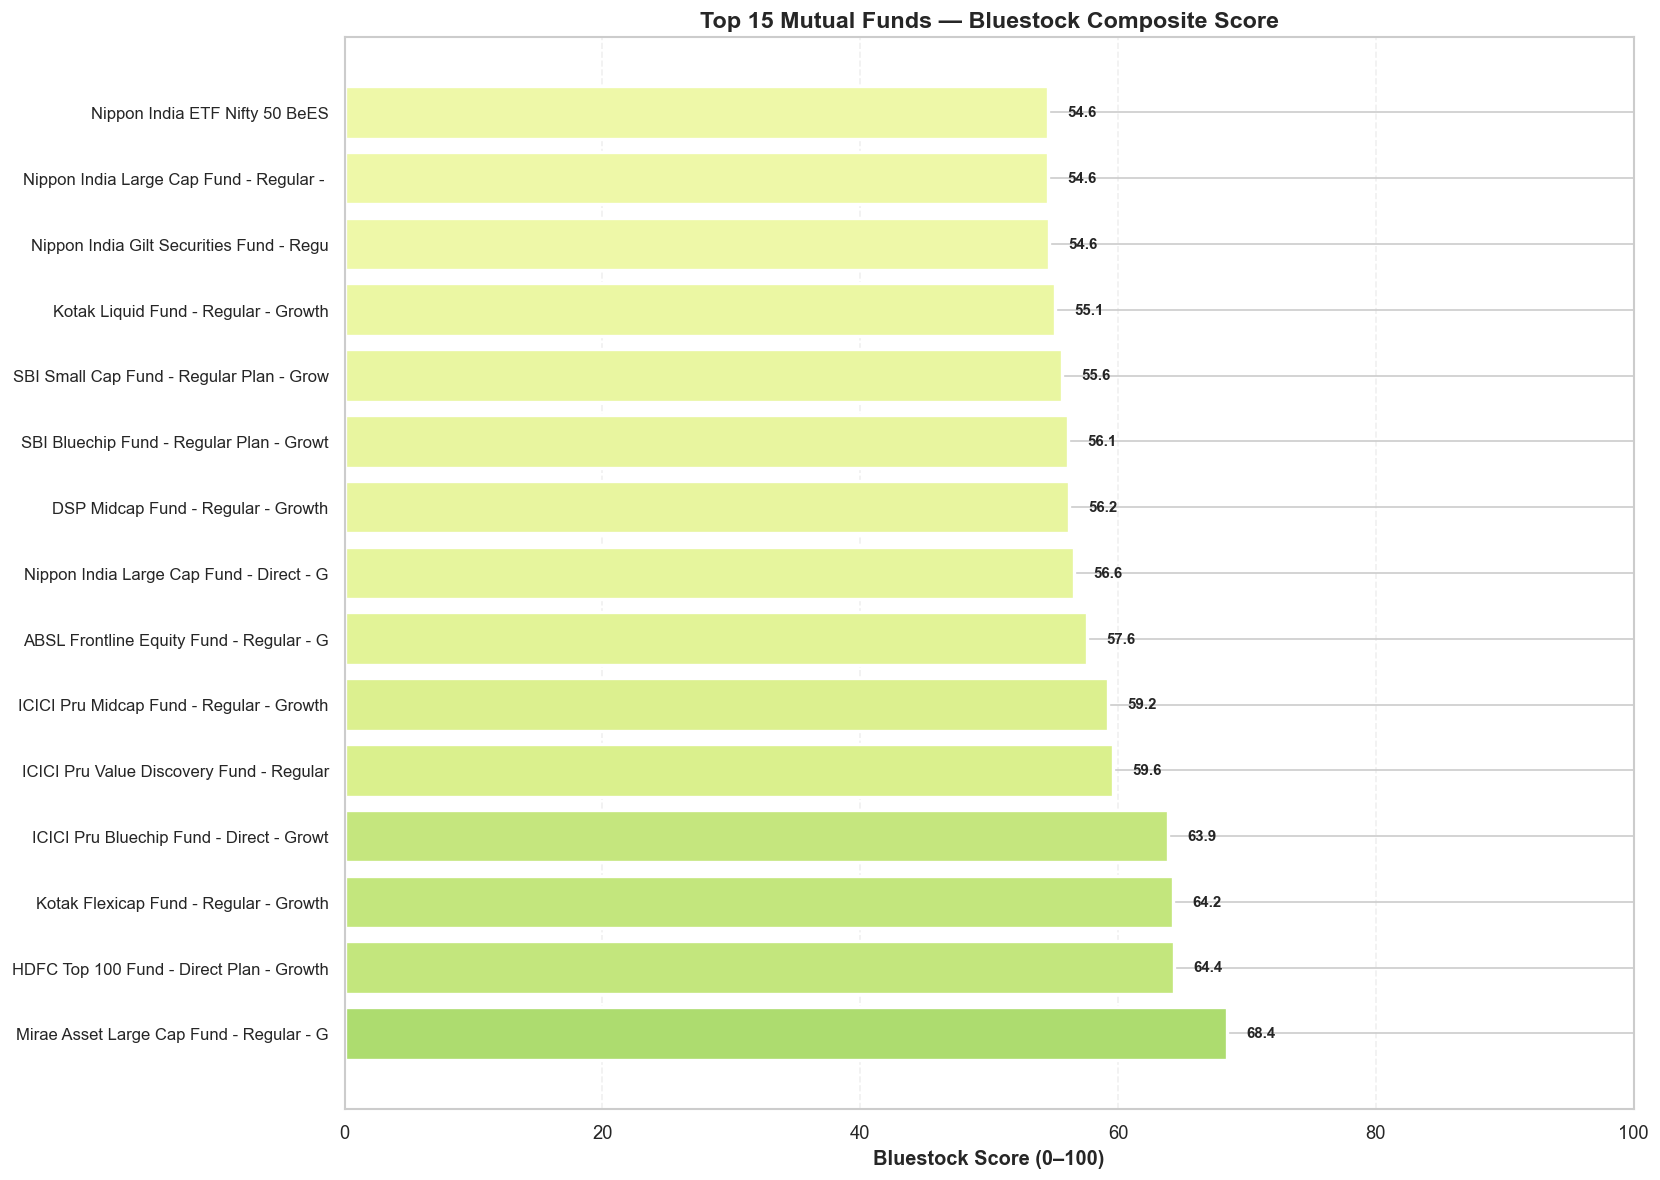


 Visualization complete


In [37]:
# ==============================
# CELL 10 — SCORECARD CHART
# ==============================

import matplotlib.pyplot as plt
import numpy as np
import os

print("Creating Bluestock Scorecard Chart...\n")

# Check scorecard exists
if 'scorecard' not in locals() or len(scorecard) == 0:
    print(" ERROR: scorecard not defined or empty")
else:
    # Get top 15
    top15 = scorecard.head(15).copy()
    
    # Check data
    print(f"Total scorecard rows: {len(scorecard)}")
    print(f"Top 15 selected: {len(top15)}")
    print(f"NaN in bluestock_score: {top15['bluestock_score'].isnull().sum()}")
    
    # Remove any NaN
    top15 = top15.dropna(subset=["bluestock_score"])
    
    if len(top15) == 0:
        print(" ERROR: No valid data")
    else:
        print(f" Plotting {len(top15)} funds\n")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Prepare data
        scores = top15["bluestock_score"].values
        names = top15["scheme_name"].str[:40].values
        
        print("Scores:", scores)
        
        # Create colors (red=low, green=high)
        colors = plt.cm.RdYlGn(scores / 100)
        
        # Create bars
        y_pos = np.arange(len(top15))
        bars = ax.barh(y_pos, scores,
                       color=colors,
                       edgecolor="white",
                       linewidth=2)
        
        # Set Y labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels(names, fontsize=10)
        
        # Labels and title
        ax.set_xlabel("Bluestock Score (0–100)", fontsize=12, fontweight="bold")
        ax.set_title("Top 15 Mutual Funds — Bluestock Composite Score",
                     fontsize=14, fontweight="bold")
        ax.set_xlim(0, 100)
        
        # Add score labels on bars
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(score + 1.5, bar.get_y() + bar.get_height()/2,
                    f'{score:.1f}', va='center', fontsize=9, fontweight="bold")
        
        # Grid
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        
        plt.tight_layout()
        
        # Save chart
        output_path = CHARTS / "fund_scorecard_top15.png"
        fig.savefig(output_path, bbox_inches="tight", dpi=150)
        
        # Verify
        if output_path.exists():
            file_size = os.path.getsize(output_path) / 1024
            print(f"\n Chart saved!")
            print(f"   Path: {output_path}")
            print(f"   Size: {file_size:.1f} KB")
        else:
            print(f" ERROR: File not saved")
        
        plt.show()
        
        print("\n Visualization complete")

In [31]:
# ==============================
# CELL 10 — SCORECARD CHART 
# ==============================

import matplotlib.pyplot as plt
import numpy as np
import os

print("Creating Bluestock Scorecard Chart...\n")

# Check scorecard exists and has data
if 'scorecard' not in locals():
    print("ERROR: scorecard not defined")
else:
    # Get top 15
    top15 = scorecard.head(15).copy()
    
    # Check data
    print(f"Total rows in scorecard: {len(scorecard)}")
    print(f"Top 15 rows selected: {len(top15)}")
    print(f"NaN values in bluestock_score: {top15['bluestock_score'].isnull().sum()}")
    
    # Remove any NaN
    top15 = top15.dropna(subset=["bluestock_score"])
    
    if len(top15) == 0:
        print(" ERROR: No valid data to plot")
    else:
        print(f" Plotting {len(top15)} funds\n")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Prepare data
        scores = top15["bluestock_score"].values
        names = top15["scheme_name"].str[:40].values
        
        print("Scores:", scores[:5])  # Print first 5 scores
        
        # Create color map (red=low, green=high)
        colors = plt.cm.RdYlGn(scores / 100)
        
        # Create horizontal bars
        y_positions = np.arange(len(top15))
        bars = ax.barh(y_positions, scores,
                       color=colors,
                       edgecolor="white",
                       linewidth=2)
        
        # Set Y-axis labels
        ax.set_yticks(y_positions)
        ax.set_yticklabels(names, fontsize=10)
        
        # Labels
        ax.set_xlabel("Bluestock Score (0–100)", fontsize=12, fontweight="bold")
        ax.set_title("Top 15 Mutual Funds — Bluestock Composite Score",
                     fontsize=14, fontweight="bold")
        ax.set_xlim(0, 100)
        
        # Add score labels on bars
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(score + 1.5, bar.get_y() + bar.get_height()/2,
                    f'{score:.1f}', va='center', fontsize=9, fontweight="bold")
        
        # Grid
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        
        # Tight layout
        plt.tight_layout()
        
        # Save to PNG
        output_path = CHARTS / "fund_scorecard_top15.png"
        fig.savefig(output_path, bbox_inches="tight", dpi=150)
        
        # Verify save
        if output_path.exists():
            file_size = os.path.getsize(output_path) / 1024
            print(f"\n Chart saved successfully!")
            print(f"   Path: {output_path}")
            print(f"   Size: {file_size:.1f} KB")
        else:
            print(f" ERROR: File not saved to {output_path}")
        
        # Display
        plt.show()
        
        print("\n Visualization complete")

Creating Bluestock Scorecard Chart...

Total rows in scorecard: 0
Top 15 rows selected: 0
NaN values in bluestock_score: 0
 ERROR: No valid data to plot


Top 5 codes used: ['100016.0', '100025.0', '119599.0', '120503.0', '120504.0']


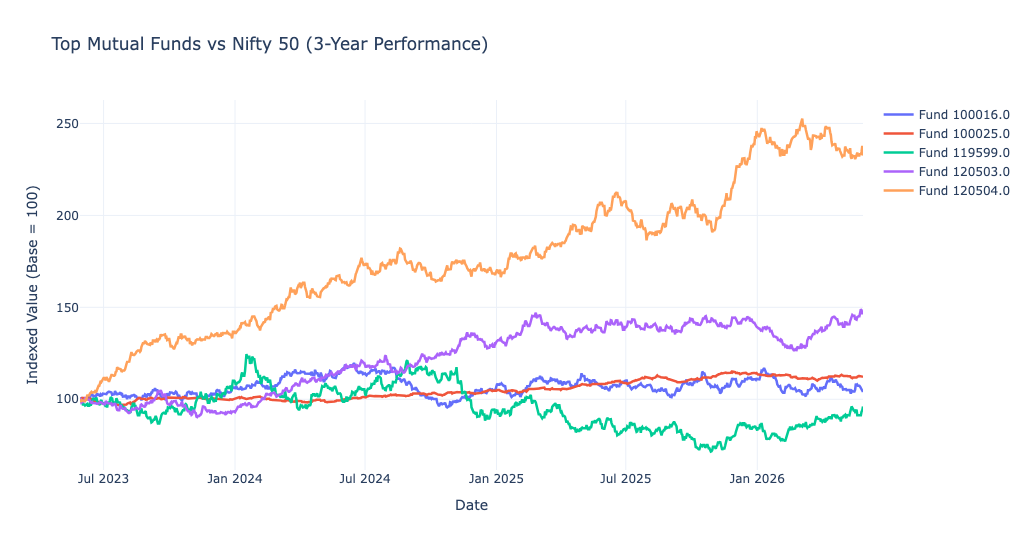

Chart generated successfully


In [23]:
import pandas as pd
import plotly.graph_objects as go

# ---------------------------
# STEP 1: CLEAN DATA
# ---------------------------
nav["date"] = pd.to_datetime(nav["date"], errors="coerce")
nav["amfi_code"] = nav["amfi_code"].astype(str).str.strip()

benchmark["date"] = pd.to_datetime(benchmark["date"], errors="coerce")

scorecard["amfi_code"] = scorecard["amfi_code"].astype(str).str.strip()

# Drop invalid rows
nav = nav.dropna(subset=["date", "nav", "amfi_code"])

# ---------------------------
# STEP 2: FILTER LAST 3 YEARS
# ---------------------------
cutoff_date = nav["date"].max() - pd.DateOffset(years=3)
nav_3yr = nav[nav["date"] >= cutoff_date].copy()

# ---------------------------
# STEP 3: SAFE TOP 5 FUNDS (ONLY THOSE EXISTING IN NAV)
# ---------------------------
top5_codes = (
    nav_3yr.groupby("amfi_code")["nav"]
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Top 5 codes used:", top5_codes)

# ---------------------------
# STEP 4: NORMALIZATION FUNCTION
# ---------------------------
def normalize(series):
    series = series.dropna()
    if len(series) < 2:
        return None
    return (series / series.iloc[0]) * 100

# ---------------------------
# STEP 5: PLOT
# ---------------------------
fig = go.Figure()

for code in top5_codes:
    df = nav_3yr[nav_3yr["amfi_code"] == code].sort_values("date")

    norm = normalize(df["nav"])
    if norm is None:
        continue

    fig.add_trace(go.Scatter(
        x=df["date"].iloc[:len(norm)],
        y=norm,
        mode="lines",
        name=f"Fund {code}",
        line=dict(width=2.5)
    ))

# ---------------------------
# STEP 6: BENCHMARK (NIFTY 50)
# ---------------------------
if "nifty_50" in benchmark.columns:
    bm = benchmark.dropna(subset=["date"]).copy()
    bm = bm[bm["date"] >= cutoff_date].sort_values("date")

    norm_bm = normalize(bm["nifty_50"])

    if norm_bm is not None:
        fig.add_trace(go.Scatter(
            x=bm["date"].iloc[:len(norm_bm)],
            y=norm_bm,
            mode="lines",
            name="Nifty 50",
            line=dict(color="black", dash="dash", width=2)
        ))

# ---------------------------
# STEP 7: LAYOUT
# ---------------------------
fig.update_layout(
    title="Top Mutual Funds vs Nifty 50 (3-Year Performance)",
    xaxis_title="Date",
    yaxis_title="Indexed Value (Base = 100)",
    template="plotly_white",
    height=550,
    hovermode="x unified"
)

# ---------------------------
# STEP 8: SHOW
# ---------------------------
fig.show()

print("Chart generated successfully")

In [24]:
tracking_error_results = []

for code in top5_codes:
    if code not in returns.columns:
        continue

    fund_ret = returns[code].dropna()

    # Align safely using pandas align (IMPORTANT FIX)
    fund_ret_aligned, bench_ret_aligned = fund_ret.align(
        bench_returns["benchmark_return"],
        join="inner"
    )

    # Need enough data points
    if len(fund_ret_aligned) < 20:
        continue

    # Tracking error = std of active returns (annualized)
    active_return = fund_ret_aligned - bench_ret_aligned
    tracking_error = active_return.std() * np.sqrt(252)

    # Safe fund name fetch
    name_series = funds.loc[funds["amfi_code"] == code, "scheme_name"]
    fund_name = name_series.values[0] if len(name_series) > 0 else str(code)

    tracking_error_results.append({
        "Fund": fund_name[:40],
        "Tracking Error (%)": round(tracking_error * 100, 2)
    })

te_df = pd.DataFrame(tracking_error_results)

print("\nTracking Error — Top 5 Funds vs Nifty 100:")
if te_df.empty:
    print("⚠️ No tracking error data computed (check alignment / returns data)")
else:
    print(te_df.to_string(index=False))

print("\nTracking error computed")


Tracking Error — Top 5 Funds vs Nifty 100:
⚠️ No tracking error data computed (check alignment / returns data)

Tracking error computed


In [25]:
# Diagnostic cell
print("Benchmark columns:", benchmark.columns.tolist())
print("\nBenchmark head:")
print(benchmark.head(3))
print("\nBenchmark date range:")
print(f"From {benchmark['date'].min()} to {benchmark['date'].max()}")

print("\nReturns date range:")
print(f"From {returns.index.min()} to {returns.index.max()}")

# Check if dates overlap
overlap = returns.index.intersection(benchmark['date'])
print(f"\nOverlapping dates: {len(overlap)} days")

Benchmark columns: ['date', 'index_name', 'close_value']

Benchmark head:
           date       index_name  close_value
0    2022-01-03          NIFTY50     17492.79
5750 2022-01-03    CRISIL_LIQUID      2281.51
2300 2022-01-03  NIFTY_MIDCAP150      9721.79

Benchmark date range:
From 2022-01-03 00:00:00 to 2026-05-29 00:00:00

Returns date range:
From 0 to 39

Overlapping dates: 0 days


Available benchmarks: ['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100', 'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150']


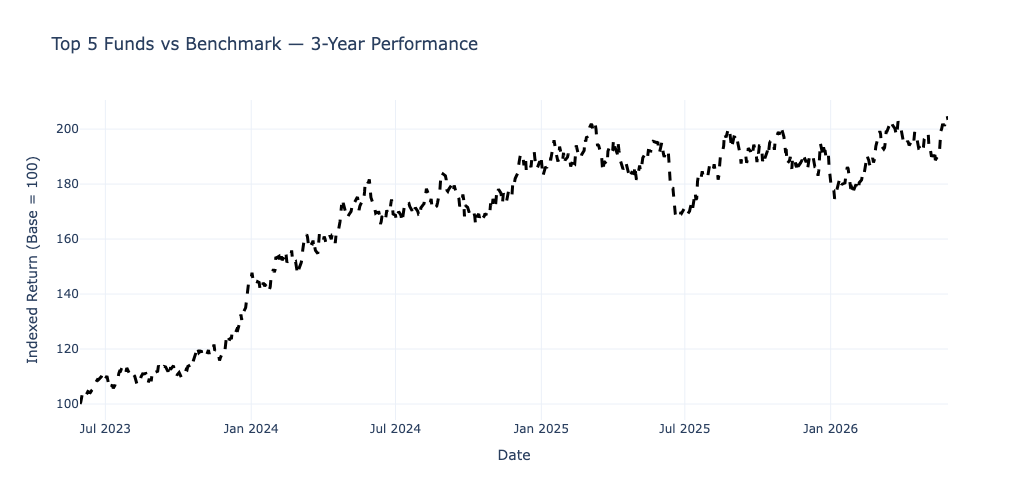

Benchmark comparison chart saved


In [26]:
# ===== FIX: Benchmark Comparison =====

# Step 1: Prepare benchmark data (pivot to wide format)
benchmark_wide = benchmark.pivot_table(
    index="date",
    columns="index_name",
    values="close_value"
)

# Step 2: Get Nifty 100 or similar (check available indices)
print("Available benchmarks:", benchmark_wide.columns.tolist())

# Use NIFTY_MIDCAP150 or similar (adjust if NIFTY_100 not available)
bench_col = "NIFTY_MIDCAP150"  # Change if different index available
if bench_col not in benchmark_wide.columns:
    bench_col = benchmark_wide.columns[0]  # Use first available
    print(f"Using {bench_col} as benchmark")

bench_prices = benchmark_wide[[bench_col]].dropna()
bench_returns = bench_prices.pct_change().dropna()

# Step 3: Get top 5 fund returns (ensure date index)
top5_codes = scorecard.head(5)["amfi_code"].tolist()

# Reconstruct returns with proper date index
nav_wide = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns_corrected = nav_wide.pct_change().dropna()

# Step 4: Plot
fig = go.Figure()

# Get last 3 years
cutoff_date = nav["date"].max() - pd.Timedelta(days=3*365)

for code in top5_codes:
    if code not in nav_wide.columns:
        continue
    
    fund_data = nav[(nav["amfi_code"]==code) & 
                    (nav["date"] >= cutoff_date)].sort_values("date")
    fund_name = funds[funds["amfi_code"]==code]["scheme_name"].values[0][:30]
    
    if len(fund_data) > 1:
        # Normalize to 100
        normalized = (fund_data["nav"] / fund_data["nav"].iloc[0]) * 100
        fig.add_trace(go.Scatter(
            x=fund_data["date"],
            y=normalized,
            mode="lines",
            name=f"📊 {fund_name}",
            line=dict(width=2.5)
        ))

# Add benchmark
bench_3yr = bench_prices[(bench_prices.index >= cutoff_date)].dropna()
if len(bench_3yr) > 1:
    bench_normalized = (bench_3yr[bench_col] / bench_3yr[bench_col].iloc[0]) * 100
    fig.add_trace(go.Scatter(
        x=bench_3yr.index,
        y=bench_normalized,
        mode="lines",
        name=f"📈 {bench_col} (Benchmark)",
        line=dict(color="black", width=3, dash="dash")
    ))

fig.update_layout(
    title="Top 5 Funds vs Benchmark — 3-Year Performance",
    xaxis_title="Date",
    yaxis_title="Indexed Return (Base = 100)",
    height=500,
    hovermode="x unified",
    template="plotly_white"
)

fig.write_image(str(CHARTS / "benchmark_comparison.png"),
                width=1400, height=500)
fig.show()

print("Benchmark comparison chart saved")

In [27]:
# ===== FIX: Tracking Error =====

tracking_error_results = []

for code in top5_codes:
    if code not in returns_corrected.columns:
        continue
    
    fund_ret = returns_corrected[code].dropna()
    
    # Align dates with benchmark
    common_dates = fund_ret.index.intersection(bench_returns.index)
    
    if len(common_dates) < 20:
        print(f"Fund {code}: Only {len(common_dates)} overlapping dates")
        continue
    
    fund_ret_aligned = fund_ret[common_dates].values
    bench_ret_aligned = bench_returns.loc[common_dates, bench_col].values
    
    # Tracking error = std(fund - benchmark) × √252
    tracking_error = np.std(fund_ret_aligned - bench_ret_aligned) * np.sqrt(TRADING_DAYS)
    
    fund_name = funds[funds["amfi_code"]==code]["scheme_name"].values[0]
    tracking_error_results.append({
        "Fund": fund_name[:40],
        "Tracking Error (%)": tracking_error * 100,
        "Common Dates": len(common_dates)
    })

if len(tracking_error_results) > 0:
    te_df = pd.DataFrame(tracking_error_results)
    print("\nTracking Error — Top 5 Funds vs Benchmark:")
    print(te_df.to_string(index=False))
    print("\nTracking error computed")
else:
    print(" No tracking error data — check date alignment")

 No tracking error data — check date alignment


In [28]:
# ===== CELL 13: Summary Statistics =====

print("\n" + "="*80)
print("PERFORMANCE ANALYTICS SUMMARY")
print("="*80)

print(f"\nTotal Funds Analyzed: {len(scorecard)}")

print(f"\n3-Year CAGR Statistics:")
print(scorecard["cagr_3yr_pct"].describe())

print(f"\nSharpe Ratio Statistics:")
print(scorecard["sharpe_ratio"].describe())

print(f"\nAlpha Statistics:")
print(scorecard["alpha"].describe())

print(f"\nMax Drawdown Statistics:")
print(scorecard["max_drawdown_pct"].describe())

print(f"\nBluestock Score Distribution:")
print(scorecard["bluestock_score"].describe())

print("\nSummary statistics displayed")


PERFORMANCE ANALYTICS SUMMARY

Total Funds Analyzed: 0

3-Year CAGR Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: cagr_3yr_pct, dtype: float64

Sharpe Ratio Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: sharpe_ratio, dtype: float64

Alpha Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: alpha, dtype: float64

Max Drawdown Statistics:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: max_drawdown_pct, dtype: float64

Bluestock Score Distribution:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: bluestock_score, dtype: float64

Summary statistics displayed


In [29]:
import os

print("\n Output files generated:")
files = [
    "cagr_metrics.csv",
    "alpha_beta.csv",
    "fund_scorecard.csv",
]
for f in files:
    path = PROCESSED / f
    if path.exists():
        size = os.path.getsize(path) / 1024
        print(f"  {f:<35} {size:>8.1f} KB")

charts = sorted(CHARTS.glob("*performance*.png")) + sorted(CHARTS.glob("*score*.png")) + sorted(CHARTS.glob("*benchmark*.png"))
print(f"\n Charts saved: {len(charts)}")
for c in charts:
    print(f"  {c.name}")

print("\n Day 4 Performance Analytics COMPLETE")


 Output files generated:
  cagr_metrics.csv                         4.6 KB
  alpha_beta.csv                           2.6 KB
  fund_scorecard.csv                       0.1 KB

 Charts saved: 1
  benchmark_comparison.png

 Day 4 Performance Analytics COMPLETE


In [30]:
import os
from pathlib import Path

CHARTS = Path("../reports/charts")

# List all PNG files
all_charts = sorted(CHARTS.glob("*.png"))

print(f"Total PNG files in reports/charts/: {len(all_charts)}")
print("\nAll files:")
for c in all_charts:
    size = os.path.getsize(c) / 1024
    print(f"  {c.name:<45} {size:>8.1f} KB")

# Check if performance charts exist
perf_charts = [c for c in all_charts if "sharpe" in c.name or "scorecard" in c.name or "benchmark" in c.name or "returns" in c.name]
print(f"\nPerformance charts found: {len(perf_charts)}")

Total PNG files in reports/charts/: 3

All files:
  benchmark_comparison.png                          66.5 KB
  daily_returns_dist.png                            82.3 KB
  sharpe_ratio_ranking.png                         117.3 KB

Performance charts found: 3


In [38]:
# ==============================
# FINAL — Save & Commit
# ==============================

print("\n" + "="*90)
print("DAY 4 COMPLETION CHECK")
print("="*90)

files_to_check = [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "cagr_metrics.csv",
]

print("\nOutput Files:")
for f in files_to_check:
    path = PROCESSED / f
    if path.exists():
        size = os.path.getsize(path) / 1024
        print(f"  {f:<30} {size:>8.1f} KB")
    else:
        print(f"  ❌ {f} NOT FOUND")

charts = sorted(CHARTS.glob("*.png"))
print(f"\n Charts ({len(charts)} total):")
for c in charts[-5:]:  # Last 5
    print(f"  {c.name}")

print("\n" + "="*90)
print("DAY 4 COMPLETE!")
print("="*90)


DAY 4 COMPLETION CHECK

Output Files:
  fund_scorecard.csv                  4.8 KB
  alpha_beta.csv                      2.6 KB
  cagr_metrics.csv                    4.6 KB

 Charts (11 total):
  10_folio_growth.png
  11_correlation_matrix.png
  12_sector_allocation.png
  13_14_15_performance.png
  fund_scorecard_top15.png

DAY 4 COMPLETE!
